In [1]:
import numpy as np
import pandas as pd

# Slim KG for Benchmark (Apr 14)

### Modifying gene-disease GEO data (irrelavant)

In [28]:
# irrelavant

df = pd.read_csv("/home/vmottaqi/kg/drug_data/gene-disease/edges_GEO_disease_gene_IA_new_final_4112025.csv", index_col=0)
df

,source,relation,target,standardized_value,sign,dataset,source_type,target_type
0,Eczema,increases expression of,PKP3,1.571547,1,GEO Signatures of Differentially Expressed Gen...,Disease,Gene
1,Eczema,increases expression of,SFPQ,1.747156,1,GEO Signatures of Differentially Expressed Gen...,Disease,Gene
2,Eczema,increases expression of,HMOX2,1.594428,1,GEO Signatures of Differentially Expressed Gen...,Disease,Gene
3,Eczema,increases expression of,MAP7D1,2.038568,1,GEO Signatures of Differentially Expressed Gen...,Disease,Gene
4,Eczema,increases expression of,ERLIN1,1.828282,1,GEO Signatures of Differentially Expressed Gen...,Disease,Gene
...,...,...,...,...,...,...,...,...
139795,Malignant tumor of pancreas,decreases expression of,EPS8L1,-1.324579,-1,GEO Signatures of Differentially Expressed Gen...,Disease,Gene
139796,Malignant tumor of pancreas,decreases expression of,RHOJ,-1.176439,-1,GEO Signatures of Differentially Expressed Gen...,Disease,Gene
139797,Malignant tumor of pancreas,decreases expression of,SLC38A10,-1.179299,-1,GEO Signatures of Differentially Expressed Gen...,Disease,Gene
139798,Malignant tumor of pancreas,decreases expression of,PPP1R12A,-1.377895,-1,GEO Signatures of Differentially Expressed Gen...,Disease,Gene


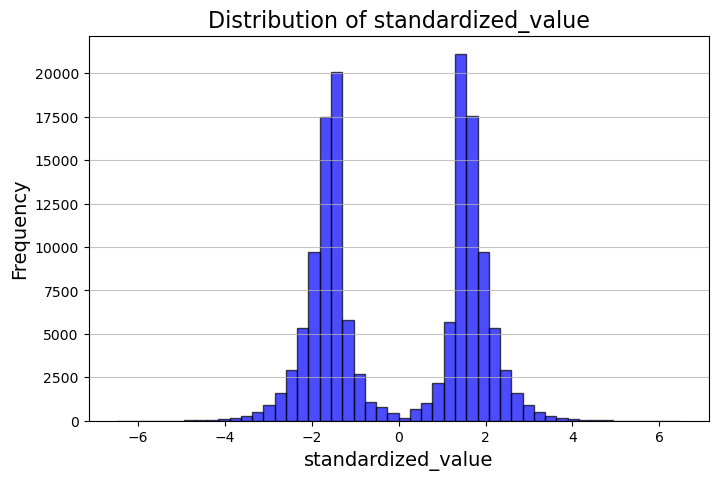

In [23]:
import matplotlib.pyplot as plt

# Plot the distribution of the 'standardized_value' column
plt.figure(figsize=(8, 5))
plt.hist(df['standardized_value'].dropna(), bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title('Distribution of standardized_value', fontsize=16)
plt.xlabel('standardized_value', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.75)

# Show the plot
plt.show()

In [14]:
print(df['source'].nunique())
print(df['target'].nunique())

163
18516


In [29]:
import numpy as np

# Step 1: Swap the 'source' and 'target' columns.
df['temp'] = df['source']
df['source'] = df['target']
df['target'] = df['temp']
df.drop(columns='temp', inplace=True)

# Step 2: Swap the 'source_type' and 'target_type' columns.
df['temp'] = df['source_type']
df['source_type'] = df['target_type']
df['target_type'] = df['temp']
df.drop(columns='temp', inplace=True)

# Step 3: Rename "standardized_value" to "original_weight".
df.rename(columns={'standardized_value': 'original_weight'}, inplace=True)

# Step 4: Add new columns: 'new_weights' as NaN and override 'dataset' with "GEO".
df['new_weights'] = np.nan
# df['dataset'] = "GEO"  # Overriding any previous value.

# Step 5: Update the relation column:
#         Replace "increases expression of" → "upregulated in" and 
#         "decreases expression of" → "downregulated in".
df['relation'] = df['relation'].str.strip().str.lower()
df['relation'] = df['relation'].replace({
    'increases expression of': 'upregulated in',
    'decreases expression of': 'downregulated in'
})

# Step 6: Filter rows where original_weight > 2 or original_weight < -2.
df_final = df[(df['original_weight'] > 1) | (df['original_weight'] < -1)].copy()

# Optional: Reorder columns to match your KG format.
kg_columns = ['source', 'relation', 'target', 'original_weight', 'sign', 'source_type', 'target_type', 'dataset', 'new_weights']
df_final = df_final[kg_columns]

df_final


,source,relation,target,original_weight,sign,source_type,target_type,dataset,new_weights
0,PKP3,upregulated in,Eczema,1.571547,1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
1,SFPQ,upregulated in,Eczema,1.747156,1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
2,HMOX2,upregulated in,Eczema,1.594428,1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
3,MAP7D1,upregulated in,Eczema,2.038568,1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
4,ERLIN1,upregulated in,Eczema,1.828282,1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
...,...,...,...,...,...,...,...,...,...
139795,EPS8L1,downregulated in,Malignant tumor of pancreas,-1.324579,-1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
139796,RHOJ,downregulated in,Malignant tumor of pancreas,-1.176439,-1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
139797,SLC38A10,downregulated in,Malignant tumor of pancreas,-1.179299,-1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
139798,PPP1R12A,downregulated in,Malignant tumor of pancreas,-1.377895,-1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN


In [30]:
print(df_final['source'].nunique())
print(df_final['target'].nunique())

18409
163


In [31]:
df_final.to_csv("/home/vmottaqi/kg/drug_data/gene-disease/edges_GEO_disease_gene_IA_new_final_Apr14.csv", index=False)

## Checkings

In [2]:
import pandas as pd
kg = pd.read_csv("/home/vmottaqi/kg/kg_versions/KG_edges_Vincent_slim_Mar282025.csv")
kg

/tmp/ipykernel_1512991/50549846.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv("/home/vmottaqi/kg/kg_versions/KG_edges_Vincent_slim_Mar282025.csv")


,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
0,100000085.0,causes,ABDOMINAL PAIN,0.21,-1.0,Chemical,Disease,SIDEr,0.21
1,100000085.0,causes,GASTROINTESTINAL DISCOMFORT,0.21,-1.0,Chemical,Disease,SIDEr,0.21
2,100000085.0,causes,ABDOMINAL PAIN,0.05,-1.0,Chemical,Disease,SIDEr,0.05
3,100000085.0,causes,GASTROINTESTINAL DISCOMFORT,0.05,-1.0,Chemical,Disease,SIDEr,0.05
4,100000085.0,causes,ABDOMINAL PAIN,0.06,-1.0,Chemical,Disease,SIDEr,0.06
...,...,...,...,...,...,...,...,...,...
6074727,CES1,has disease,COLONIC NEOPLASMS,NaN,0.0,Gene,Disease,PharmKG,NaN
6074728,CES1,has disease,CHRONIC HEPATITIS C INFECTION,NaN,0.0,Gene,Disease,PharmKG,NaN
6074729,CES1,has disease,STROKE DISORDER,NaN,0.0,Gene,Disease,PharmKG,NaN
6074730,F12,has disease,DEATH,NaN,0.0,Gene,Disease,PharmKG,NaN


In [3]:
print(kg['dataset'].unique())

['SIDEr' 'nSIDES' 'BioGPS Cell Line Gene Expression Profiles'
 'GDSC Cell Line Gene Expression Profiles'
 'Heiser et al., PNAS, 2011 Cell Line Gene Expression Profiles'
 'HPA Cell Line Gene Expression Profiles'
 'Klijn et al., Nat. Biotechnol., 2015 Cell Line Gene Expression Profiles'
 'CCLE Cell Line Gene Expression Profiles' 'PrimeKG'
 'CMAP Signatures of Differentially Expressed Genes for Small Molecules'
 'DepMap' 'Roadmap Epigenomics Cell and Tissue Gene Expression Profiles'
 'IUPHAR merged with Stitch'
 'BioGPS Human Cell Type and Tissue Gene Expression Profiles'
 'CCLE Proteomics' 'repoDB (unmtid-shinyapps.net)' 'UniProtKB' 'clue.io'
 'PharmacoDB Cell viability' 'CTD Gene-Disease Associations'
 'DISEASES Curated Gene-Disease Assocation Evidence Scores'
 'GAD Gene-Disease Associations'
 'PhosphoSitePlus Phosphosite-Disease Associations'
 'HPO Gene-Disease Associations' 'OMIM Gene-Disease Associations'
 'HuGE Navigator Gene-Phenotype Associations' 'PharmKG']


In [5]:
# Filter out rows where the 'dataset' column has the value 'PrimeKG'
df1_filtered = kg[kg['dataset'] = 'PrimeKG']

primekg = pd.read_csv("/home/vmottaqi/kg/drug_data/PrimeKG_chemical_disease_Apr92025.csv")
# Merge the filtered first DataFrame with the second DataFrame
df = pd.concat([df1_filtered, primekg], ignore_index=True)

# Display the merged DataFrame
df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
2827131,59227,causes,HYPERTENSION,NaN,-1.0,Chemical,Disease,PrimeKG,NaN
2827132,134715568,treats,HYPERTENSION,NaN,1.0,Chemical,Disease,PrimeKG,NaN
2827133,13791,causes,HYPERTENSION,NaN,-1.0,Chemical,Disease,PrimeKG,NaN
2827134,4756,causes,HYPERTENSION,NaN,-1.0,Chemical,Disease,PrimeKG,NaN
2827135,7172,causes,HYPERTENSION,NaN,-1.0,Chemical,Disease,PrimeKG,NaN
...,...,...,...,...,...,...,...,...,...
2860397,115355.0,treats,"TYROSINEMIA, TYPE I",NaN,1.0,Chemical,Disease,PrimeKG,NaN
2860398,25151352.0,treats,TENOSYNOVIAL GIANT CELL TUMOR,NaN,1.0,Chemical,Disease,PrimeKG,NaN
2860399,25151352.0,treats,PIGMENTED VILLONODULAR SYNOVITIS,NaN,1.0,Chemical,Disease,PrimeKG,NaN
2860400,5284583.0,causes,DEPERSONALIZATION DISORDER,NaN,-1.0,Chemical,Disease,PrimeKG,NaN


In [19]:

# primekg.head()

In [20]:
df.shape

(6111075, 9)

Stats

In [6]:
import pandas as pd

main_df = kg

# Assume main_df is your knowledge graph dataframe.

# ---------------------------
# 1. Total number of unique nodes
# ---------------------------
unique_nodes = set(main_df['source'].unique()).union(set(main_df['target'].unique()))
total_unique_nodes = len(unique_nodes)
print("Total unique nodes:", total_unique_nodes)

# ---------------------------
# 2. Unique nodes per entity type
# ---------------------------
# Get the union of all entity types from source_type and target_type
entity_types = set(main_df['source_type'].unique()).union(set(main_df['target_type'].unique()))

entity_node_counts = {}
for etype in entity_types:
    # For each type, get nodes appearing as source with that type and as target with that type
    nodes_from_source = set(main_df.loc[main_df['source_type'] == etype, 'source'].unique())
    nodes_from_target = set(main_df.loc[main_df['target_type'] == etype, 'target'].unique())
    total_nodes = nodes_from_source.union(nodes_from_target)
    entity_node_counts[etype] = len(total_nodes)

print("\nUnique nodes per entity type:")
for etype, count in entity_node_counts.items():
    print(f"  {etype}: {count}")

# ---------------------------
# 3. Unique relations and total edge counts for each entity pair
# ---------------------------
# Group by source_type, target_type, and relation, and count the number of edges.
relation_counts = (
    main_df.groupby(['source_type', 'target_type', 'relation'])
    .size()
    .reset_index(name='edge_count')
)

print("\nUnique relations and total edge counts for each entity pair:")
print(relation_counts)

# Optionally, group by entity pair and print the relation details in a structured format.
entity_pair_relations = {}
for (src_type, tgt_type), group in relation_counts.groupby(['source_type', 'target_type']):
    entity_pair_relations[(src_type, tgt_type)] = group[['relation', 'edge_count']].to_dict('records')

print("\nEntity pair relations:")
for pair, rels in entity_pair_relations.items():
    print(f"  {pair}:")
    for r in rels:
        print(f"    Relation: {r['relation']}, Edge count: {r['edge_count']}")


Total unique nodes: 82235

Unique nodes per entity type:
  Chemical: 18314
  Protein: 18664
  Disease: 16590
  Gene: 24348
  Cell Line: 4351

Unique relations and total edge counts for each entity pair:
   source_type target_type                 relation  edge_count
0    Cell Line     Disease          associates with        2568
1     Chemical   Cell Line               sensitizes      145629
2     Chemical     Disease                   causes      724527
3     Chemical     Disease                   treats       15050
4     Chemical        Gene  decreases expression of      455053
5     Chemical        Gene  increases expression of      463052
6     Chemical     Protein                activates        7727
7     Chemical     Protein                 inhibits        8374
8         Gene   Cell Line        over-expressed in     1865502
9         Gene   Cell Line       under-expressed in     1079606
10        Gene     Disease              has disease      787419
11        Gene     Protein   

In [7]:
# Group by source_type and target_type and aggregate the relation and edge_count into a list of dictionaries.
# Group by source_type and target_type and aggregate the relations into a dictionary.
relation_dict_df = (
    relation_counts.groupby(['source_type', 'target_type'])
    .apply(lambda group: {row['relation']: row['edge_count'] for _, row in group.iterrows()})
    .reset_index(name='relations')
)

relation_dict_df

,source_type,target_type,relations
0,Cell Line,Disease,{'associates with': 2568}
1,Chemical,Cell Line,{'sensitizes': 145629}
2,Chemical,Disease,"{'causes': 724527, 'treats': 15050}"
3,Chemical,Gene,"{'decreases expression of': 455053, 'increases..."
4,Chemical,Protein,"{'activates': 7727, 'inhibits': 8374}"
5,Gene,Cell Line,"{'over-expressed in': 1865502, 'under-expresse..."
6,Gene,Disease,{'has disease': 787419}
7,Gene,Protein,{'encodes': 20215}
8,Protein,Cell Line,"{'over-expressed in': 357640, 'under-expressed..."


Revisions of nodes and edges

In [2]:
df = kg
kg.shape

(6074732, 9)

In [31]:
import pandas as pd

# Assume df is your master Knowledge Graph DataFrame.

# 1. Identify all chemical nodes. We assume chemicals are marked in the 'source' column when source_type is "Chemical".
all_chemicals = set(kg.loc[kg["source_type"] == "Chemical", "source"].unique())

# 2. Identify chemical nodes that have a direct edge to any disease node.
chemicals_with_disease_edge = set(
    kg.loc[(kg["source_type"] == "Chemical") & (kg["target_type"] == "Disease"), "source"].unique()
)

# 3. Determine chemicals with no direct edge to any disease node.
chemicals_without_disease_edge = all_chemicals - chemicals_with_disease_edge

# Print the result.
print("Number of chemical nodes with no direct edge to any disease node:", len(chemicals_without_disease_edge))


Number of chemical nodes with no direct edge to any disease node: 13042


In [47]:
# Filter the dataframe for rows where source_type is 'Chemical' and target_type is 'Disease'
# chemical_disease_df_c = kg[(kg['source_type'] == 'Chemical') & (kg['target_type'] == 'Disease')& (kg['relation'] == 'causes')& (kg['dataset'] == 'PrimeKG')]
# chemical_disease_df_t = kg[(kg['source_type'] == 'Chemical') & (kg['target_type'] == 'Disease')& (kg['relation'] == 'treats') & (kg['dataset'] == 'PrimeKG')]

# # Get the unique number of chemicals in the source column
# unique_chemicals_t = chemical_disease_df_t['source'].nunique()
# unique_chemicals_c = chemical_disease_df_c['source'].nunique()

# print(f"Unique number of chemicals in the treat column: {unique_chemicals_t}")
# print(f"Unique number of chemicals in the cause column: {unique_chemicals_c}")

# # Find the intersection of chemicals in both dataframes
# common_chemicals = set(chemical_disease_df_c['source']).intersection(set(chemical_disease_df_t['source']))

# print(f"Number of chemicals present in both: {len(common_chemicals)}")
# print("Chemicals present in both:")
# print(common_chemicals)


Unique number of chemicals in the treat column: 2048
Unique number of chemicals in the cause column: 2259
Number of chemicals present in both: 1237
Chemicals present in both:
{'6917.0', '444036', '2519', '3158', '26987', '9906855.0', '5665.0', '59768', '56339', '5280793', '54675783', '5320', '6116.0', '4761', '5311066.0', '9651.0', '6291.0', '60871', '5339.0', '123600.0', '54675779.0', '36462.0', '2088.0', '1110.0', '73416022.0', '4011', '441140', '443879.0', '1775', '2733526', '10007', '24011.0', '1983', '441074', '54454.0', '444025.0', '5362129.0', '3305', '6099', '9941379.0', '135398745', '5311412.0', '146037278', '150311', '6167.0', '5852.0', '10531', '5744.0', '2554', '892', '3348.0', '243', '3385.0', '5834.0', '68873', '5282452.0', '6099959', '6445540.0', '6918462.0', '4567.0', '2771.0', '2955.0', '5161', '16666.0', '135398658.0', '4583', '10630', '137', '10324367', '5910', '176870.0', '1046', '5282226.0', '6674.0', '2710', '59768.0', '444', '23897.0', '12986439.0', '3825', '6083

In [38]:
# in PrimeKG
chemical_disease_df1 = kg[(kg['dataset'] == 'PrimeKG') & (kg['relation'] == 'treats')]
# print(chemical_disease_df1['target_type'].unique())
chemical_disease_df1

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
2827132,134715568,treats,HYPERTENSION,NaN,1.0,Chemical,Disease,PrimeKG,NaN
2827148,5464343,treats,HYPERTENSION,NaN,1.0,Chemical,Disease,PrimeKG,NaN
2827150,56330,treats,HYPERTENSION,NaN,1.0,Chemical,Disease,PrimeKG,NaN
2827151,2162,treats,HYPERTENSION,NaN,1.0,Chemical,Disease,PrimeKG,NaN
2827153,5484727,treats,HYPERTENSION,NaN,1.0,Chemical,Disease,PrimeKG,NaN
...,...,...,...,...,...,...,...,...,...
2860390,2733526.0,treats,"CARCINOMA, DUCTAL, BREAST",NaN,1.0,Chemical,Disease,PrimeKG,NaN
2860397,115355.0,treats,"TYROSINEMIA, TYPE I",NaN,1.0,Chemical,Disease,PrimeKG,NaN
2860398,25151352.0,treats,TENOSYNOVIAL GIANT CELL TUMOR,NaN,1.0,Chemical,Disease,PrimeKG,NaN
2860399,25151352.0,treats,PIGMENTED VILLONODULAR SYNOVITIS,NaN,1.0,Chemical,Disease,PrimeKG,NaN


In [45]:
chemical_disease_df_t.shape

(7392, 9)

In [ ]:
Number of chemicals present in both: 1475

In [5]:
# Filter rows where 'source_type' is 'Protein' and 'target_type' is 'Cell Line'
protein_to_cell_line_df = df[(df['source_type'] == 'Gene') & (df['target_type'] == 'Disease')]

# Display the filtered dataframe
protein_to_cell_line_df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
5287313,SLC29A3,has disease,HISTIOCYTOSIS WITH JOINT CONTRACTURES AND SENS...,2.880087,0.0,Gene,Disease,CTD Gene-Disease Associations,NaN
5287314,SLC29A3,has disease,"HISTIOCYTOSIS, SINUS",2.880087,0.0,Gene,Disease,CTD Gene-Disease Associations,NaN
5287315,SLC29A3,has disease,LANGERHANS CELL HISTIOCYTOSIS,2.880087,0.0,Gene,Disease,CTD Gene-Disease Associations,NaN
5287316,SLC29A3,has disease,HYPERTRICHOSIS (DISEASE),2.880087,0.0,Gene,Disease,CTD Gene-Disease Associations,NaN
5287317,RPL27A,has disease,SKIN HYPERPIGMENTATION,2.880087,0.0,Gene,Disease,CTD Gene-Disease Associations,NaN
...,...,...,...,...,...,...,...,...,...
6074727,CES1,has disease,COLONIC NEOPLASMS,NaN,0.0,Gene,Disease,PharmKG,NaN
6074728,CES1,has disease,CHRONIC HEPATITIS C INFECTION,NaN,0.0,Gene,Disease,PharmKG,NaN
6074729,CES1,has disease,STROKE DISORDER,NaN,0.0,Gene,Disease,PharmKG,NaN
6074730,F12,has disease,DEATH,NaN,0.0,Gene,Disease,PharmKG,NaN


In [41]:
print(protein_to_cell_line_df['dataset'].unique())

['CTD Gene-Disease Associations'
 'DISEASES Curated Gene-Disease Assocation Evidence Scores'
 'GAD Gene-Disease Associations'
 'PhosphoSitePlus Phosphosite-Disease Associations'
 'HPO Gene-Disease Associations' 'OMIM Gene-Disease Associations'
 'HuGE Navigator Gene-Phenotype Associations' 'PharmKG']


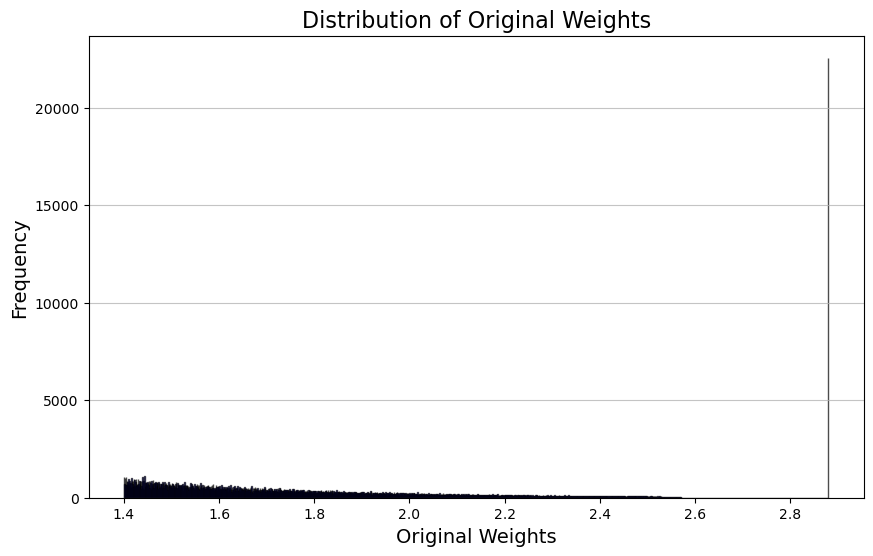

In [6]:
import matplotlib.pyplot as plt

# Drop NaN values from the 'original_weights' column
weights = protein_to_cell_line_df['original_weights'].dropna()

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(weights, bins=1530, color='blue', alpha=0.7, edgecolor='black')
plt.title('Distribution of Original Weights', fontsize=16)
plt.xlabel('Original Weights', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.75)

# Show the plot
plt.show()

## Step 1. reducing edges and integrating data

In [9]:
import pandas as pd
kg = pd.read_csv("/home/vmottaqi/kg/kg_versions/KG_edges_Vincent_slim_Mar282025.csv")
kg

/tmp/ipykernel_1512991/50549846.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv("/home/vmottaqi/kg/kg_versions/KG_edges_Vincent_slim_Mar282025.csv")


,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
0,100000085.0,causes,ABDOMINAL PAIN,0.21,-1.0,Chemical,Disease,SIDEr,0.21
1,100000085.0,causes,GASTROINTESTINAL DISCOMFORT,0.21,-1.0,Chemical,Disease,SIDEr,0.21
2,100000085.0,causes,ABDOMINAL PAIN,0.05,-1.0,Chemical,Disease,SIDEr,0.05
3,100000085.0,causes,GASTROINTESTINAL DISCOMFORT,0.05,-1.0,Chemical,Disease,SIDEr,0.05
4,100000085.0,causes,ABDOMINAL PAIN,0.06,-1.0,Chemical,Disease,SIDEr,0.06
...,...,...,...,...,...,...,...,...,...
6074727,CES1,has disease,COLONIC NEOPLASMS,NaN,0.0,Gene,Disease,PharmKG,NaN
6074728,CES1,has disease,CHRONIC HEPATITIS C INFECTION,NaN,0.0,Gene,Disease,PharmKG,NaN
6074729,CES1,has disease,STROKE DISORDER,NaN,0.0,Gene,Disease,PharmKG,NaN
6074730,F12,has disease,DEATH,NaN,0.0,Gene,Disease,PharmKG,NaN


In [ ]:
print(kg['dataset'].unique())

NameError: name 'kg' is not defined

In [ ]:
# STEP 1: Filter out rows where the 'dataset' column has the value 'PrimeKG'

In [10]:
# Filter out rows where the 'dataset' column has the value 'PrimeKG'
df1_filtered = kg[kg['dataset'] != 'PrimeKG']

primekg = pd.read_csv("/home/vmottaqi/kg/drug_data/primekg/PrimeKG_chemical_disease_Apr92025.csv")
# Merge the filtered first DataFrame with the second DataFrame
df = pd.concat([df1_filtered, primekg], ignore_index=True)

# Display the merged DataFrame
df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
0,100000085.0,causes,ABDOMINAL PAIN,0.21,-1.0,Chemical,Disease,SIDEr,0.21
1,100000085.0,causes,GASTROINTESTINAL DISCOMFORT,0.21,-1.0,Chemical,Disease,SIDEr,0.21
2,100000085.0,causes,ABDOMINAL PAIN,0.05,-1.0,Chemical,Disease,SIDEr,0.05
3,100000085.0,causes,GASTROINTESTINAL DISCOMFORT,0.05,-1.0,Chemical,Disease,SIDEr,0.05
4,100000085.0,causes,ABDOMINAL PAIN,0.06,-1.0,Chemical,Disease,SIDEr,0.06
...,...,...,...,...,...,...,...,...,...
6111070,445643.0,causes,POLYNEUROPATHY,NaN,-1.0,Chemical,Disease,PrimeKG_contraindication,NaN
6111071,445643.0,causes,NERVOUS SYSTEM DISEASES,NaN,-1.0,Chemical,Disease,PrimeKG_contraindication,NaN
6111072,16134395.0,causes,POLYNEUROPATHY,NaN,-1.0,Chemical,Disease,PrimeKG_contraindication,NaN
6111073,16134395.0,causes,NERVOUS SYSTEM DISEASES,NaN,-1.0,Chemical,Disease,PrimeKG_contraindication,NaN


In [14]:
# add chemical-chemical similarity
df_chem_chem = pd.read_csv("/home/vmottaqi/kg/drug_data/chem_chem_similairty_reliable_Apr112025.csv")
df = pd.concat([df, df_chem_chem], ignore_index=True)
df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
0,100000085.0,causes,ABDOMINAL PAIN,0.21,-1.0,Chemical,Disease,SIDEr,0.21
1,100000085.0,causes,GASTROINTESTINAL DISCOMFORT,0.21,-1.0,Chemical,Disease,SIDEr,0.21
2,100000085.0,causes,ABDOMINAL PAIN,0.05,-1.0,Chemical,Disease,SIDEr,0.05
3,100000085.0,causes,GASTROINTESTINAL DISCOMFORT,0.05,-1.0,Chemical,Disease,SIDEr,0.05
4,100000085.0,causes,ABDOMINAL PAIN,0.06,-1.0,Chemical,Disease,SIDEr,0.06
...,...,...,...,...,...,...,...,...,...
6497385,44487032.0,is similar to,44485039.0,1.00,0.0,Chemical,Chemical,Chemical Checker,1.00
6497386,44487032.0,is similar to,44487024.0,1.00,0.0,Chemical,Chemical,Chemical Checker,1.00
6497387,44485039.0,is similar to,44487024.0,1.00,0.0,Chemical,Chemical,Chemical Checker,1.00
6497388,2880726.0,is similar to,5346285.0,1.00,0.0,Chemical,Chemical,Chemical Checker,1.00


In [ ]:
# STEP 2
# target and source uppercase
# threshold for chemical-disease (0.2)

In [35]:
df.shape

(2904087, 9)

In [15]:
df.dropna(subset=['source'], inplace=True)
df.dropna(subset=['target'], inplace=True)
df.shape

(6497390, 9)

In [16]:
# STEP 1

# df = kg
# remove cell line entity
df = df[~((df["source_type"] == "Cell Line"))]
df = df[~((df["target_type"] == "Cell Line"))]

# df['source'] = df['source'].str.upper()
# df['target'] = df['target'].str.upper()

# For rows where source_type is 'Chemical', convert the source value to integer.
df.loc[df["source_type"] == "Chemical", "source"] = (
    df.loc[df["source_type"] == "Chemical", "source"]
      .astype(float)
      .astype(int)
)

df.loc[df["target_type"] == "Chemical", "target"] = (
    df.loc[df["target_type"] == "Chemical", "target"]
      .astype(float)
      .astype(int)
)

# df_temp = df[(df['original_weights'].isna()) | (df['original_weights'] >= 1.8) | (df['source_type'] == 'Gene') & (df['target_type'] == 'Disease')]


In [23]:
df.shape # 481417

(2904087, 9)

In [18]:
print(df['dataset'].unique())

['SIDEr' 'nSIDES'
 'CMAP Signatures of Differentially Expressed Genes for Small Molecules'
 'IUPHAR merged with Stitch' 'repoDB (unmtid-shinyapps.net)' 'UniProtKB'
 'CTD Gene-Disease Associations'
 'DISEASES Curated Gene-Disease Assocation Evidence Scores'
 'GAD Gene-Disease Associations'
 'PhosphoSitePlus Phosphosite-Disease Associations'
 'HPO Gene-Disease Associations' 'OMIM Gene-Disease Associations'
 'HuGE Navigator Gene-Phenotype Associations' 'PharmKG'
 'PrimeKG_indication' 'PrimeKG_offlabeluse' 'PrimeKG_contraindication'
 'Chemical Checker']


In [21]:
unique_datasets = df[df['relation'] == 'treats']['dataset'].unique()
print(unique_datasets)

['repoDB (unmtid-shinyapps.net)' 'PrimeKG_indication'
 'PrimeKG_offlabeluse']


## Step 2. Gene-Disease datasets

In [ ]:
# add new Gene-Disease

In [20]:
df_d_1 = pd.read_csv("/home/vmottaqi/kg/drug_data/gene-disease/disease_gene_disignatlas_reliable_Apr14.csv")
df_d_1

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
0,PITX1,upregulated in,Retinoblastoma,NaN,1,Gene,Disease,DiSignAtlas,NaN
1,LINC02154,upregulated in,Retinoblastoma,NaN,1,Gene,Disease,DiSignAtlas,NaN
2,IGF2BP1,upregulated in,Retinoblastoma,NaN,1,Gene,Disease,DiSignAtlas,NaN
3,TK1,upregulated in,Retinoblastoma,NaN,1,Gene,Disease,DiSignAtlas,NaN
4,LMX1A,upregulated in,Retinoblastoma,NaN,1,Gene,Disease,DiSignAtlas,NaN
...,...,...,...,...,...,...,...,...,...
3565549,CALB1,downregulated in,Clear Cell Ependymoma,NaN,-1,Gene,Disease,DiSignAtlas,NaN
3565550,NPHS2,downregulated in,Clear Cell Ependymoma,NaN,-1,Gene,Disease,DiSignAtlas,NaN
3565551,HPD,downregulated in,Clear Cell Ependymoma,NaN,-1,Gene,Disease,DiSignAtlas,NaN
3565552,SLC22A8,downregulated in,Clear Cell Ependymoma,NaN,-1,Gene,Disease,DiSignAtlas,NaN


In [28]:
print(df_d_1['target'].nunique())

1245


In [25]:
df_d_2 = pd.read_csv("/home/vmottaqi/kg/drug_data/gene-disease/Gene_Disease_hetionet_Apr11.csv")
df_d_2

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
0,BSG,upregulated in,lung cancer,NaN,1,Gene,Disease,Hetionet,NaN
1,JAK2,upregulated in,malaria,NaN,1,Gene,Disease,Hetionet,NaN
2,DSG3,upregulated in,lung cancer,NaN,1,Gene,Disease,Hetionet,NaN
3,PDGFA,upregulated in,obesity,NaN,1,Gene,Disease,Hetionet,NaN
4,ZBED2,upregulated in,malaria,NaN,1,Gene,Disease,Hetionet,NaN
...,...,...,...,...,...,...,...,...,...
15349,LRRN3,downregulated in,acquired immunodeficiency syndrome,NaN,-1,Gene,Disease,Hetionet,NaN
15350,GCH1,downregulated in,nicotine dependence,NaN,-1,Gene,Disease,Hetionet,NaN
15351,SLC4A7,downregulated in,malaria,NaN,-1,Gene,Disease,Hetionet,NaN
15352,KANK2,downregulated in,polycystic ovary syndrome,NaN,-1,Gene,Disease,Hetionet,NaN


In [26]:
df_d_3 = pd.read_csv("/home/vmottaqi/kg/drug_data/gene-disease/edges_GEO_disease_gene_IA_new_final_Apr14.csv")
df_d_3

,source,relation,target,original_weight,sign,source_type,target_type,dataset,new_weights
0,PKP3,upregulated in,Eczema,1.571547,1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
1,SFPQ,upregulated in,Eczema,1.747156,1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
2,HMOX2,upregulated in,Eczema,1.594428,1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
3,MAP7D1,upregulated in,Eczema,2.038568,1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
4,ERLIN1,upregulated in,Eczema,1.828282,1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
...,...,...,...,...,...,...,...,...,...
131789,EPS8L1,downregulated in,Malignant tumor of pancreas,-1.324579,-1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
131790,RHOJ,downregulated in,Malignant tumor of pancreas,-1.176439,-1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
131791,SLC38A10,downregulated in,Malignant tumor of pancreas,-1.179299,-1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN
131792,PPP1R12A,downregulated in,Malignant tumor of pancreas,-1.377895,-1,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN


In [34]:
print(df["dataset"].value_counts())
# dfff = df[df['dataset'] == 'CMAP Signatures of Differentially Expressed Genes for Small Molecules']
# dfff

dataset
CMAP Signatures of Differentially Expressed Genes for Small Molecules    918105
nSIDES                                                                   618062
Chemical Checker                                                         388189
CTD Gene-Disease Associations                                            360087
HPO Gene-Disease Associations                                            223795
HuGE Navigator Gene-Phenotype Associations                               135079
SIDEr                                                                     80586
PrimeKG_contraindication                                                  48956
GAD Gene-Disease Associations                                             42252
UniProtKB                                                                 20215
IUPHAR merged with Stitch                                                 16101
DISEASES Curated Gene-Disease Assocation Evidence Scores                  15316
PrimeKG_indication              

In [41]:
df.shape

(2904087, 9)

In [51]:
len(mask_gene_disease == True)

2904087

In [42]:
# Create mask for rows with source_type "gene" and target_type "disease".
mask_gene_disease = (df['source_type'] == 'Gene') & (df['target_type'] == 'Disease')

# Print the unique dataset values for those rows.
unique_datasets = df.loc[mask_gene_disease, 'dataset'].unique()
# print("Unique dataset values for rows with Gene in source_type and Disease in target_type:")
# print(unique_datasets)

# Remove those rows from the dataframe.
df = df.loc[~mask_gene_disease].copy()
df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
0,100000085,causes,ABDOMINAL PAIN,0.21,-1.0,Chemical,Disease,SIDEr,0.21
1,100000085,causes,GASTROINTESTINAL DISCOMFORT,0.21,-1.0,Chemical,Disease,SIDEr,0.21
2,100000085,causes,ABDOMINAL PAIN,0.05,-1.0,Chemical,Disease,SIDEr,0.05
3,100000085,causes,GASTROINTESTINAL DISCOMFORT,0.05,-1.0,Chemical,Disease,SIDEr,0.05
4,100000085,causes,ABDOMINAL PAIN,0.06,-1.0,Chemical,Disease,SIDEr,0.06
...,...,...,...,...,...,...,...,...,...
6497385,44487032,is similar to,44485039.0,1.00,0.0,Chemical,Chemical,Chemical Checker,1.00
6497386,44487032,is similar to,44487024.0,1.00,0.0,Chemical,Chemical,Chemical Checker,1.00
6497387,44485039,is similar to,44487024.0,1.00,0.0,Chemical,Chemical,Chemical Checker,1.00
6497388,2880726,is similar to,5346285.0,1.00,0.0,Chemical,Chemical,Chemical Checker,1.00


In [46]:
df = pd.concat([df, df_d_1, df_d_2, df_d_3], ignore_index=True)
df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,100000085,causes,ABDOMINAL PAIN,0.21,-1.0,Chemical,Disease,SIDEr,0.21,NaN
1,100000085,causes,GASTROINTESTINAL DISCOMFORT,0.21,-1.0,Chemical,Disease,SIDEr,0.21,NaN
2,100000085,causes,ABDOMINAL PAIN,0.05,-1.0,Chemical,Disease,SIDEr,0.05,NaN
3,100000085,causes,GASTROINTESTINAL DISCOMFORT,0.05,-1.0,Chemical,Disease,SIDEr,0.05,NaN
4,100000085,causes,ABDOMINAL PAIN,0.06,-1.0,Chemical,Disease,SIDEr,0.06,NaN
...,...,...,...,...,...,...,...,...,...,...
5829365,EPS8L1,downregulated in,Malignant tumor of pancreas,NaN,-1.0,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN,-1.324579
5829366,RHOJ,downregulated in,Malignant tumor of pancreas,NaN,-1.0,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN,-1.176439
5829367,SLC38A10,downregulated in,Malignant tumor of pancreas,NaN,-1.0,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN,-1.179299
5829368,PPP1R12A,downregulated in,Malignant tumor of pancreas,NaN,-1.0,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN,-1.377895


In [47]:
df.shape

(5829370, 10)

In [48]:
# STEP 2

# Count the total rows before filtering
total_rows_before = df[(df['source_type'] == 'Chemical') & 
                       (df['target_type'] == 'Disease') & 
                       (~df['new_weights'].isna())].shape[0]

# Remove rows where source_type is 'Chemical', target_type is 'Disease', and new_weight <= 0.2
df = df[~((df['source_type'] == 'Chemical') & 
          (df['target_type'] == 'Disease') & 
          (df['relation'] == 'causes') &
          (~df['new_weights'].isna()) & 
          (df['new_weights'] < 0.32))]

# Count the total rows after filtering
total_rows_after = df[(df['source_type'] == 'Chemical') & 
                      (df['target_type'] == 'Disease') & 
                      (~df['new_weights'].isna())].shape[0]

# Calculate the number of rows removed
rows_removed = total_rows_before - total_rows_after

print(f"Total rows before filtering: {total_rows_before}")
print(f"Total rows after filtering: {total_rows_after}")
print(f"Number of rows removed: {rows_removed}")


Total rows before filtering: 698648
Total rows after filtering: 139892
Number of rows removed: 558756


In [49]:
df.shape

(5270614, 10)

In [50]:
df.drop_duplicates(inplace=True)
df.shape

/tmp/ipykernel_1512991/3054484884.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)


(4028335, 10)

## Step 3. Dis-Dis & LLM merging

In [52]:
df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
48,100000085,causes,DIARRHEAL DISEASE,0.35,-1.0,Chemical,Disease,SIDEr,0.35,NaN
79,100000085,causes,HEADACHE DISORDER,0.37,-1.0,Chemical,Disease,SIDEr,0.37,NaN
120,100000085,causes,PAIN,0.32,-1.0,Chemical,Disease,SIDEr,0.32,NaN
121,100000085,causes,PAIN,0.35,-1.0,Chemical,Disease,SIDEr,0.35,NaN
167,100000085,causes,INJECTION SITE REACTION,0.33,-1.0,Chemical,Disease,SIDEr,0.33,NaN
...,...,...,...,...,...,...,...,...,...,...
5829365,EPS8L1,downregulated in,Malignant tumor of pancreas,NaN,-1.0,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN,-1.324579
5829366,RHOJ,downregulated in,Malignant tumor of pancreas,NaN,-1.0,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN,-1.176439
5829367,SLC38A10,downregulated in,Malignant tumor of pancreas,NaN,-1.0,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN,-1.179299
5829368,PPP1R12A,downregulated in,Malignant tumor of pancreas,NaN,-1.0,Gene,Disease,GEO Signatures of Differentially Expressed Gen...,NaN,-1.377895


In [55]:
df_dis_dis = pd.read_csv("/home/vmottaqi/kg/drug_data/primekg/PrimeKG_disease_disease_Apr112025.csv")
df_dis_dis.head()

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights
0,adrenal cortex disease,similar to,adrenocortical insufficiency,NaN,0,Disease,Disease,PrimeKG_dis_dis,NaN
1,genetic alopecia,similar to,"alopecia, isolated",NaN,0,Disease,Disease,PrimeKG_dis_dis,NaN
2,hemorrhagic disease,similar to,"inherited bleeding disorder, platelet-type",NaN,0,Disease,Disease,PrimeKG_dis_dis,NaN
3,blood platelet disease,similar to,"inherited bleeding disorder, platelet-type",NaN,0,Disease,Disease,PrimeKG_dis_dis,NaN
4,Mendelian disease,similar to,"inherited bleeding disorder, platelet-type",NaN,0,Disease,Disease,PrimeKG_dis_dis,NaN


In [54]:
print(df_dis_dis['source'].nunique())

29524


In [ ]:
df = pd.concat([df, df_dis_dis], ignore_index=True)
df

In [61]:
df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,100000085,causes,DIARRHEAL DISEASE,0.35,-1.0,Chemical,Disease,SIDEr,0.35,NaN
1,100000085,causes,HEADACHE DISORDER,0.37,-1.0,Chemical,Disease,SIDEr,0.37,NaN
2,100000085,causes,PAIN,0.32,-1.0,Chemical,Disease,SIDEr,0.32,NaN
3,100000085,causes,PAIN,0.35,-1.0,Chemical,Disease,SIDEr,0.35,NaN
4,100000085,causes,INJECTION SITE REACTION,0.33,-1.0,Chemical,Disease,SIDEr,0.33,NaN
...,...,...,...,...,...,...,...,...,...,...
4115254,Abnormal mandible condylar process morphology,similar to,Abnormal oral morphology,NaN,0.0,Disease,Disease,PrimeKG_phen_phen,NaN,NaN
4115255,Abnormal mandible coronoid process morphology,similar to,Abnormality of the mandible,NaN,0.0,Disease,Disease,PrimeKG_phen_phen,NaN,NaN
4115256,Abnormal mandible coronoid process morphology,similar to,Abnormal oral morphology,NaN,0.0,Disease,Disease,PrimeKG_phen_phen,NaN,NaN
4115257,Abnormal mandibular symphysis morphology,similar to,Abnormal joint morphology,NaN,0.0,Disease,Disease,PrimeKG_phen_phen,NaN,NaN


In [ ]:
import pickle
# Load the dictionary
with open('/home/vmottaqi/kg/stitch/disease_terms_groups_Apr112025.pkl', 'rb') as f:
    disease_groups = pickle.load(f)
disease_groups

In [69]:
# main_df = df.copy()

In [73]:
# Create a reverse mapping: each synonym (lowercase) maps to its representative key.
reverse_mapping = {}
for representative, synonyms in disease_groups.items():
    for syn in synonyms:
        reverse_mapping[syn.lower()] = representative.lower()

# Define a helper function that maps a disease term to its representative.
def map_disease(term):
    if isinstance(term, str):
        # Return the representative if found, else the original term.
        return reverse_mapping.get(term.lower(), term)
    return term

# Update the disease terms in the main_df:
# For rows where the source_type is 'Disease', update the 'source' column.
mask_source = df['source_type'] == 'Disease'
df.loc[mask_source, 'source'] = df.loc[mask_source, 'source'].str.lower().apply(map_disease)

# For rows where the target_type is 'Disease', update the 'target' column.
mask_target = df['target_type'] == 'Disease'
df.loc[mask_target, 'target'] = df.loc[mask_target, 'target'].str.lower().apply(map_disease)

# Optionally, print the unique disease names after mapping to verify.
disease_terms = pd.concat([
    df.loc[df['source_type'] == 'Disease', 'source'],
    df.loc[df['target_type'] == 'Disease', 'target']
]).dropna().unique().tolist()


In [74]:
len(disease_terms)

13563

In [75]:
df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,original_weight
0,100000085,causes,diarrheal disease,0.35,-1.0,Chemical,Disease,SIDEr,0.35,NaN
1,100000085,causes,headache disorder,0.37,-1.0,Chemical,Disease,SIDEr,0.37,NaN
2,100000085,causes,pain,0.32,-1.0,Chemical,Disease,SIDEr,0.32,NaN
3,100000085,causes,pain,0.35,-1.0,Chemical,Disease,SIDEr,0.35,NaN
4,100000085,causes,injection site reaction,0.33,-1.0,Chemical,Disease,SIDEr,0.33,NaN
...,...,...,...,...,...,...,...,...,...,...
4115254,abnormal mandible coronoid process morphology,similar to,abnormality of the mouth,NaN,0.0,Disease,Disease,PrimeKG_phen_phen,NaN,NaN
4115255,abnormal mandible coronoid process morphology,similar to,abnormality of the mandible,NaN,0.0,Disease,Disease,PrimeKG_phen_phen,NaN,NaN
4115256,abnormal mandible coronoid process morphology,similar to,abnormality of the mouth,NaN,0.0,Disease,Disease,PrimeKG_phen_phen,NaN,NaN
4115257,abnormal mandibular ramus morphology,similar to,abnormal joint morphology,NaN,0.0,Disease,Disease,PrimeKG_phen_phen,NaN,NaN


In [77]:
df.drop_duplicates(inplace=True)
df.shape

(3893013, 10)

In [78]:
df.to_csv("/home/vmottaqi/kg/kg_versions/KG_edges_intermediate_v1_Apr142025_1pm.csv", index=False)

## Step 4. conflicts

In [ ]:
df1 = pd.read_csv("/home/vmottaqi/kg/kg_versions/KG_edges_intermediate_v1_Apr142025_1pm.csv")
df = df1.copy()
df

In [ ]:
# For rows where source_type is 'Chemical', convert the source value to integer.
df.loc[df["source_type"] == "Chemical", "source"] = (
    df.loc[df["source_type"] == "Chemical", "source"]
      .astype(float)
      .astype(int)
)

df.loc[df["target_type"] == "Chemical", "target"] = (
    df.loc[df["target_type"] == "Chemical", "target"]
      .astype(float)
      .astype(int)
)


In [92]:
# STEP 3

# Conflicting relaitons
# Groups rows by the source and target pair.
# Identifies groups where the relation value is not unique (i.e. there is more than one relation per pair).
# Prints the number of rows that belong to these conflict groups and shows a summary of the unique relations per conflicting pair.
# Removes all rows that belong to any source–target pair with conflicting relations.

import pandas as pd

# Assume df is your loaded dataframe

# Step 1: Identify conflict groups (source, target pairs where relation is not unique)
conflict_groups = df.groupby(["source", "target"]).filter(lambda g: g["relation"].nunique() > 1)

# Count of conflicting rows
num_conflict_rows = len(conflict_groups)
print("Number of conflict rows:", num_conflict_rows)

# Step 2: Print a summary of the conflict pairs with their unique relations
conflict_summary = (conflict_groups
                    .groupby(["source", "target"])["relation"]
                    .unique()
                    .reset_index())
print("Unique relation conflicts for each (source, target):")
print(conflict_summary)

# Step 3: Remove all rows that belong to conflicting (source, target) pairs
# First, get a set of all (source, target) pairs that are in conflict
conflict_pairs = set(tuple(x) for x in conflict_summary[["source", "target"]].values)

# Define a helper function to check if a row belongs to a conflict pair
def is_conflict(row):
    return (row["source"], row["target"]) in conflict_pairs

# Keep only rows that are not in conflict
df_clean1 = df[~df.apply(is_conflict, axis=1)]

print("DataFrame shape after removing conflict rows:", df_clean1.shape)

df = df_clean1
df = df.drop_duplicates(subset=["source", "target", 'relation'], keep='first')


Number of conflict rows: 41050
Unique relation conflicts for each (source, target):
          source    target                                           relation
0            160    P34995                              [inhibits, activates]
1            160    P35408                              [activates, inhibits]
2            160    P43088                              [activates, inhibits]
3            160    P43115                              [inhibits, activates]
4            160    P43116                              [inhibits, activates]
...          ...       ...                                                ...
20457  172430945  RPGRIP1L  [increases expression of, decreases expression...
20458  172430945    SCUBE3  [increases expression of, decreases expression...
20459  172430945       SP1  [increases expression of, decreases expression...
20460  172430945    ZNF639  [increases expression of, decreases expression...
20461  172430945    ZNF862  [increases expression of, decr

In [61]:
df_clean1.shape

(1643799, 9)

In [39]:
# df = df_clean1
# df = df.drop_duplicates(subset=["source", "target", "relation"], keep='first')

In [98]:
df.shape # 1580117

(1549599, 9)

Inhibits and Decrease expression of conflict 

In [114]:
# df = df1

In [101]:
# NEXT STEP

import pandas as pd
import numpy as np

###############################
# STEP A: Build bridging table from Chemical→Protein and Protein→Gene edges
###############################
# Extract Chemical→Protein edges.
df_cp = df[(df["source_type"] == "Chemical") & (df["target_type"] == "Protein")].copy()
# Normalize the relation strings.
df_cp["relation_norm"] = df_cp["relation"].str.strip().str.lower()
# We assume the relevant CP relations are "activates" and "inhibits"
df_cp = df_cp[df_cp["relation_norm"].isin(["activates", "inhibits"])].copy()

# Rename columns: chemical and protein.
df_cp = df_cp.rename(columns={"source": "chemical", "target": "protein", "relation_norm": "cp_relation"})

# Extract Protein→Gene edges.
df_pg = df[(df["source_type"] == "Gene") & (df["target_type"] == "Protein")].copy()
# Rename columns: protein and gene.
df_pg = df_pg.rename(columns={"source": "gene", "target": "protein"})

# Merge CP and PG on the protein field to build a bridging table.
df_bridge = pd.merge(
    df_cp[['chemical', 'protein', 'cp_relation']],
    df_pg[['protein', 'gene']],
    on='protein',
    how='inner'
)
# Now df_bridge has columns: chemical, protein, cp_relation, gene.
# (Keep the bridging info; note that one chemical may connect to one gene via multiple proteins.)


In [102]:
df_bridge

,chemical,protein,cp_relation,gene
0,70701426,P18054,inhibits,ALOX12
1,1999882,P16050,inhibits,ALOX15
2,664510,P16050,inhibits,ALOX15
3,297589,P16050,inhibits,ALOX15
4,24825377,O15296,inhibits,ALOX15B
...,...,...,...,...
14631,271,O60503,activates,ADCY9
14632,2242,Q7RTX1,activates,TAS1R1
14633,5538,Q8NFJ5,activates,GPRC5A
14634,444795,Q8NFJ5,activates,GPRC5A


In [103]:
###############################
# STEP B: Compute expected direct Chemical→Gene relation
###############################
def infer_expected_relation(relations):
    # relations: list of cp_relation values for the given chemical–gene pair.
    # For our rule:
    #   If at least one edge indicates "activates" (and none indicates "inhibits") → expected = "increases expression of"
    #   If at least one edge indicates "inhibits" (and none indicates "activates") → expected = "decreases expression of"
    #   If both appear, return "conflict".
    rels = [r for r in relations if isinstance(r, str)]
    activates = any("activates" in r for r in rels)
    inhibits = any("inhibits" in r for r in rels)
    if activates and not inhibits:
        return "increases expression of"
    elif inhibits and not activates:
        return "decreases expression of"
    elif activates and inhibits:
        return "conflict"
    else:
        return None

# Group by (chemical, gene) from the bridge and aggregate cp_relation.
bridge_summary = df_bridge.groupby(['chemical', 'gene'])['cp_relation'].apply(list).reset_index()
bridge_summary['expected_relation'] = bridge_summary['cp_relation'].apply(infer_expected_relation)

###############################
# STEP C: Merge expected relation into direct Chemical→Gene edges and mark conflicts.
###############################
# Extract direct Chemical→Gene (CG) edges.
df_cg = df[(df["source_type"] == "Chemical") & (df["target_type"] == "Gene")].copy()
# Reset index in both dataframes to ensure consistency
df_cg = df_cg.reset_index(drop=True)
bridge_summary = bridge_summary.reset_index(drop=True)

# For consistency, rename df_cg columns for merging:
# We assume df_cg uses "source" for chemical and "target" for gene.
df_cg = df_cg.rename(columns={"source": "chemical", "target": "gene"})
# Normalize the direct CG relation text.
df_cg["relation_norm"] = df_cg["relation"].str.strip().str.lower()

# Merge expected_relation from bridge_summary into df_cg.
df_cg = pd.merge(df_cg, bridge_summary[['chemical','gene','expected_relation']], on=['chemical','gene'], how='left')

# Mark a direct CG edge as conflicting if:
# (a) An expected_relation exists and is not "conflict"
# (b) and the observed relation (df_cg["relation_norm"]) does NOT equal the expected_relation.
def mark_conflict(row):
    exp_rel = row.get("expected_relation")
    obs_rel = row.get("relation_norm", "")
    if pd.notnull(exp_rel):
        return obs_rel != exp_rel
    return False

df_cg["conflict"] = df_cg.apply(mark_conflict, axis=1)
num_conflicting_cg = df_cg["conflict"].sum()
print("Number of conflicting direct Chemical→Gene edges (to be removed):", num_conflicting_cg)

# Build a set of (chemical, gene) pairs from the conflicting direct CG edges.
conflict_pairs = set(df_cg[df_cg["conflict"]][["chemical", "gene"]].apply(lambda r: (r["chemical"], r["gene"]), axis=1))

###############################
# STEP D: Remove conflicting direct Chemical→Gene edges from the master KG.
###############################
# To ensure the indices match, reset index on the master dataframe as well.
df_reset = df.reset_index(drop=True)

# Define a function that marks rows for removal if they are direct CG edges and their (source, target) is in conflict_pairs.
def mark_for_removal(row):
    if row["source_type"] == "Chemical" and row["target_type"] == "Gene":
        return (row["source"], row["target"]) in conflict_pairs
    return False

removal_mask = df_reset.apply(mark_for_removal, axis=1)
num_removed = removal_mask.sum()
print("Total number of direct Chemical→Gene edges removed from the KG:", num_removed)

# Produce the cleaned KG.
df_clean = df_reset[~removal_mask].copy()

print("Original KG shape:", df.shape)
print("Cleaned KG shape:", df_clean.shape)

Number of conflicting direct Chemical→Gene edges (to be removed): 0
Total number of direct Chemical→Gene edges removed from the KG: 0
Original KG shape: (1549599, 9)
Cleaned KG shape: (1549599, 9)


In [104]:
df = df_clean
df.shape

(1549599, 9)

In [ ]:
# NEXT STEPS (2 parts)
# chem-dis edges treats are reliable!
# (Remove Gene→Disease edges when a “treats” chemical activates a protein that connects to a gene, and that gene is linked to the disease.)

In [105]:
import pandas as pd

# Assume df is your master Knowledge Graph DataFrame.

##########################################
# PART 1: Removal Based on CP and PG Evidence
##########################################

# 1. Extract Chemical→Disease edges with relation "treats"
df_cd_treats = df[
    (df["source_type"] == "Chemical") & 
    (df["target_type"] == "Disease") & 
    (df["relation"].str.strip().str.lower() == "treats")
].copy()
# For clarity, rename the relevant columns:
df_cd_treats = df_cd_treats.rename(columns={"source": "chemical", "target": "disease"})

# 2. Extract Chemical→Protein edges where the relation is "activates"
df_cp_activates = df[
    (df["source_type"] == "Chemical") & 
    (df["target_type"] == "Protein") & 
    (df["relation"].str.strip().str.lower() == "activates")
].copy()
df_cp_activates = df_cp_activates.rename(columns={"source": "chemical", "target": "protein"})

# 3. Merge the treats CD edges with the activating CP edges (join on chemical) 
#    to associate each (chemical, disease) with proteins that the chemical activates.
df_cd_cp = pd.merge(
    df_cd_treats[['chemical','disease']],
    df_cp_activates[['chemical','protein']],
    on="chemical",
    how="inner"
)
# df_cd_cp now has columns: chemical, disease, protein.

# 4. Extract Protein→Gene (PG) edges.
#    (Assuming these edges are stored with source_type "Gene" and target_type "Protein".)
df_pg = df[
    (df["source_type"] == "Gene") & 
    (df["target_type"] == "Protein")
].copy()
df_pg = df_pg.rename(columns={"source": "gene", "target": "protein"})

# 5. Merge df_cd_cp with Protein→Gene edges on "protein" to obtain the associated genes.
df_cd_cp_gene = pd.merge(
    df_cd_cp,
    df_pg[['protein','gene']],
    on="protein",
    how="inner"
)
# df_cd_cp_gene now has: chemical, disease, protein, gene.

# 6. Construct the set of (gene, disease) pairs for which Gene→Disease edges should be removed.
remove_pairs_part1 = set(
    df_cd_cp_gene[["gene", "disease"]].apply(lambda row: (row["gene"], row["disease"]), axis=1)
)
print("Part 1: Number of (gene, disease) pairs identified for removal:", len(remove_pairs_part1))

# 7. Remove from the original KG (df) the Gene→Disease edges that match these (gene, disease) pairs.
#    (Gene→Disease edges have source_type "Gene" and target_type "Disease")
mask_remove_part1 = df.apply(
    lambda row: (row["source"], row["target"]) in remove_pairs_part1 
                if (row["source_type"]=="Gene" and row["target_type"]=="Disease") 
                else False, 
    axis=1
)
df_clean_part1 = df[~mask_remove_part1].copy()

print("Part 1: Original KG shape:", df.shape)
print("Part 1: KG shape after removal (Part 1):", df_clean_part1.shape)


Part 1: Number of (gene, disease) pairs identified for removal: 5340
Part 1: Original KG shape: (1549599, 9)
Part 1: KG shape after removal (Part 1): (1549374, 9)


In [106]:
df = df_clean_part1

In [ ]:
# Remove Gene→Disease edges when a “treats” chemical directly links to a gene with the relation "increases expression of" and that gene is connected to the same disease.

In [107]:
import pandas as pd

# Assume df is your master Knowledge Graph DataFrame.

##########################################
# PART 2: Removal Based on Direct Chemical→Gene Evidence
##########################################

# 1. Extract Chemical→Disease edges with relation "treats"
df_cd_treats = df[
    (df["source_type"] == "Chemical") &
    (df["target_type"] == "Disease") &
    (df["relation"].str.strip().str.lower() == "treats")
].copy()
df_cd_treats = df_cd_treats.rename(columns={"source": "chemical", "target": "disease"})

# 2. Extract direct Chemical→Gene edges with relation "increases expression of"
df_cg_increases = df[
    (df["source_type"] == "Chemical") & 
    (df["target_type"] == "Gene") & 
    (df["relation"].str.strip().str.lower() == "increases expression of")
].copy()
df_cg_increases = df_cg_increases.rename(columns={"source": "chemical", "target": "gene"})

# 3. Merge the CD treats edges with the direct CG edges on "chemical" so that for each chemical-disease pair,
#    you get the genes that are connected by "increases expression of"
df_cd_cg = pd.merge(
    df_cd_treats[['chemical','disease']],
    df_cg_increases[['chemical','gene']],
    on="chemical",
    how="inner"
)
# df_cd_cg now contains columns: chemical, disease, gene.

# 4. Create the set of (gene, disease) pairs that should be removed.
remove_pairs_part2 = set(
    df_cd_cg[["gene", "disease"]].apply(lambda row: (row["gene"], row["disease"]), axis=1)
)
print("Part 2: Number of (gene, disease) pairs identified for removal:", len(remove_pairs_part2))

# 5. Remove from the original KG (df) the Gene→Disease edges that match these pairs.
mask_remove_part2 = df.apply(
    lambda row: (row["source"], row["target"]) in remove_pairs_part2 
                if (row["source_type"] == "Gene" and row["target_type"] == "Disease") 
                else False, 
    axis=1
)
df_clean_part2 = df[~mask_remove_part2].copy()

print("Part 2: Original KG shape:", df.shape)
print("Part 2: KG shape after removal (Part 2):", df_clean_part2.shape)


Part 2: Number of (gene, disease) pairs identified for removal: 2093049
Part 2: Original KG shape: (1549374, 9)
Part 2: KG shape after removal (Part 2): (1541460, 9)


In [112]:
# 14,925 edges removed (Gene-Dis)
df = df_clean_part2
df.shape

(1541460, 9)

In [109]:
df.shape

(1541460, 9)

In [ ]:
# NEXT STEPS

In [ ]:
# Part 1 – Protein‐Mediated Conflict Removal:
# For every chemical–disease edge that is marked as "causes", we
# • extract the proteins that the chemical has an edge to with the relation "inhibits",
# • link those proteins to genes via gene–protein edges, and then
# • find (gene, disease) pairs where there is a direct gene–disease edge.
# In these cases the gene–disease edge should be removed.

In [ ]:
# First do the next part, then come back!

# Protein-mediated conflict: remove gene–disease edges based on a “causes” CD edge and intervening CP (“inhibits”) and PG links.

import pandas as pd

###############################################
# PART 1: Remove Gene→Disease edges based on 
# a "causes" CD edge where the chemical, via an "inhibits" CP edge,
# is linked to proteins and then to genes that are connected to the same disease.
###############################################

# 1. Extract chemical–disease edges with relation "causes"
df_cd_causes = df[
    (df["source_type"] == "Chemical") & 
    (df["target_type"] == "Disease") & 
    (df["relation"].str.strip().str.lower() == "causes")
].copy()
# Rename columns for clarity:
df_cd_causes = df_cd_causes.rename(columns={"source": "chemical", "target": "disease"})

# 2. Extract chemical→protein edges with relation "inhibits"
df_cp_inhibits = df[
    (df["source_type"] == "Chemical") & 
    (df["target_type"] == "Protein") & 
    (df["relation"].str.strip().str.lower() == "inhibits")
].copy()
df_cp_inhibits = df_cp_inhibits.rename(columns={"source": "chemical", "target": "protein"})

# 3. Merge the CD-causes and CP-inhibits edges on chemical 
#    to associate each (chemical, disease) with proteins inhibited by that chemical.
df_cd_cp = pd.merge(
    df_cd_causes[['chemical','disease']],
    df_cp_inhibits[['chemical','protein']],
    on="chemical",
    how="inner"
)
# Now df_cd_cp has columns: chemical, disease, protein.

# 4. Extract protein→gene edges.
#    (Assuming these edges are recorded with source_type "Gene" and target_type "Protein".)
df_pg = df[
    (df["source_type"] == "Gene") & 
    (df["target_type"] == "Protein")
].copy()
df_pg = df_pg.rename(columns={"source": "gene", "target": "protein"})

# 5. Merge df_cd_cp with the protein→gene edges using "protein" as key.
df_cd_cp_gene = pd.merge(
    df_cd_cp,
    df_pg[['protein','gene']],
    on="protein",
    how="inner"
)
# Now columns: chemical, disease, protein, gene.

# 6. For each row in the resulting table, the (gene, disease) pair indicates that
#    a gene connected (via an inhibited protein) to a chemical that causes the disease.
#    Build the set of (gene, disease) pairs.
remove_pairs_part1 = set(
    df_cd_cp_gene[["gene", "disease"]].apply(lambda row: (row["gene"], row["disease"]), axis=1)
)
print("Part 1: Number of (gene, disease) pairs targeted for removal:", len(remove_pairs_part1))

# 7. Remove Gene→Disease edges from the master KG.
#    (Gene→Disease edges are defined as rows with source_type=="Gene", target_type=="Disease".)
def mark_removal_part1(row):
    if row["source_type"] == "Gene" and row["target_type"] == "Disease":
        return (row["source"], row["target"]) in remove_pairs_part1
    return False

mask_remove_part1 = df.apply(mark_removal_part1, axis=1)
df_clean_part11 = df[~mask_remove_part1].copy()

print("Part 1: Original KG shape:", df.shape)
print("Part 1: KG shape after removing gene–disease edges:", df_clean_part11.shape)


Part 1: Number of (gene, disease) pairs targeted for removal: 109636
Part 1: Original KG shape: (1505215, 11)
Part 1: KG shape after removing gene–disease edges: (1502688, 11)


In [117]:
df = df_clean_part11
df.shape

(1502688, 11)

In [ ]:
# Direct CG conflict resolution: for “causes” chemical–disease edges, 
# decide whether to remove conflicting direct chemical–gene edges or the chemical–disease edge based on the majority count among direct CG edges.

In [113]:
import pandas as pd

###############################################
# PART 2: Resolve conflicts for chemical-disease "causes" edges
# based on the direct chemical→gene (CG) edges.
# For each chemical–disease pair:
#   - Join the "causes" CD edge with the direct CG edges (with relation either 
#     "increases expression of" or "decreases expression of") for that chemical,
#     but only consider those genes that are connected to the disease 
#     (via gene→disease [GD] edges).
###############################################

# 1. Extract chemical–disease (CD) edges with relation "causes"
df_cd_causes = df[
    (df["source_type"] == "Chemical") &
    (df["target_type"] == "Disease") &
    (df["relation"].str.strip().str.lower() == "causes")
].copy()
df_cd_causes = df_cd_causes.rename(columns={"source": "chemical", "target": "disease"})

# 2. Extract direct chemical→gene (CG) edges with allowed relations.
df_cg = df[
    (df["source_type"] == "Chemical") &
    (df["target_type"] == "Gene")
].copy()
df_cg = df_cg.rename(columns={"source": "chemical", "target": "gene"})
df_cg["relation_norm"] = df_cg["relation"].str.strip().str.lower()
df_cg = df_cg[df_cg["relation_norm"].isin(["increases expression of", "decreases expression of"])]

# 3. Extract gene→disease (GD) edges.
df_gd = df[
    (df["source_type"] == "Gene") &
    (df["target_type"] == "Disease")
].copy()
df_gd = df_gd.rename(columns={"source": "gene", "target": "disease"})

# 4. Join CD "causes" edges with direct CG edges on chemical.
df_cd_cg = pd.merge(
    df_cd_causes[['chemical','disease']],
    df_cg[['chemical','gene','relation_norm']],
    on="chemical",
    how="inner"
)

# Then, join with GD edges on both gene and disease to only consider genes connected to the disease.
df_cd_cg_gd = pd.merge(
    df_cd_cg,
    df_gd[['gene','disease']],
    on=['gene','disease'],
    how="inner"
)
# Now df_cd_cg_gd contains columns: chemical, disease, gene, and the direct CG relation.

# 5. Group by (chemical, disease) to count direct CG edges by type.
# The result provides, for each (chemical,disease) pair, counts for:
# "increases expression of" and "decreases expression of".
cg_counts = (df_cd_cg_gd
             .groupby(["chemical", "disease"])["relation_norm"]
             .value_counts()
             .unstack(fill_value=0)
             .reset_index())
print("Part 2: Direct CG edge counts per (chemical, disease):")
print(cg_counts)

# 6. Decide removal based on majority counts without looping over rows.
#    a) CASE 1 (Majority: increases > decreases): Remove direct CG edges with relation "decreases expression of".
#    b) CASE 2 (Majority: decreases >= increases): Remove the chemical–disease (CD) edge.
case1 = cg_counts[ cg_counts.get("increases expression of", 0) > cg_counts.get("decreases expression of", 0) ][["chemical","disease"]]
case2 = cg_counts[ cg_counts.get("increases expression of", 0) <= cg_counts.get("decreases expression of", 0) ][["chemical","disease"]]

# For CASE 1: From df_cd_cg_gd, keep only rows with "decreases expression of" that belong to case1.
remove_cg_df = pd.merge(
    df_cd_cg_gd[df_cd_cg_gd["relation_norm"] == "decreases expression of"],
    case1,
    on=["chemical","disease"],
    how="inner"
)
# Build a set of removal keys for CG edges (using chemical|gene as key).
remove_cg_keys = set(remove_cg_df.apply(lambda r: f"{r['chemical']}|{r['gene']}", axis=1))

# For CASE 2: Build a set of removal keys for CD edges.
remove_cd_keys = set(case2.apply(lambda r: f"{r['chemical']}|{r['disease']}", axis=1))

print("Part 2: Number of direct CG edges to remove (case 1):", len(remove_cg_keys))
print("Part 2: Number of CD edges to remove (case 2):", len(remove_cd_keys))

# 7. Use vectorized operations to remove flagged edges from the master KG.
# We create key columns in df for the edges we need to test.
df = df.copy()  # Work on a copy.
mask_cg = (df["source_type"]=="Chemical") & (df["target_type"]=="Gene")
mask_cd = (df["source_type"]=="Chemical") & (df["target_type"]=="Disease")

# Create keys for CG edges: "chemical|gene"
df.loc[mask_cg, "cg_key"] = df.loc[mask_cg, "source"].astype(str) + "|" + df.loc[mask_cg, "target"].astype(str)
# Create keys for CD edges: "chemical|disease"
df.loc[mask_cd, "cd_key"] = df.loc[mask_cd, "source"].astype(str) + "|" + df.loc[mask_cd, "target"].astype(str)

# Mark rows for removal if:
# - For CG edges: the key is in remove_cg_keys.
# - For CD edges: the key is in remove_cd_keys.
remove_mask = ((mask_cg) & (df["cg_key"].isin(remove_cg_keys))) | ((mask_cd) & (df["cd_key"].isin(remove_cd_keys)))

df_clean_part2 = df[~remove_mask].copy()

print("Part 2: Original KG shape:", df.shape)
print("Part 2: KG shape after conflict removals:", df_clean_part2.shape)


Part 2: Direct CG edge counts per (chemical, disease):
relation_norm   chemical                                  disease  \
0                    204  INBORN DISORDER OF PORPHYRIN METABOLISM   
1                    204                          KIDNEY DISEASES   
2                    444      CORONARY ARTERY DISEASE; THROMBOSIS   
3                    444                             HYPERTENSION   
4                    444                          KIDNEY DISEASES   
...                  ...                                      ...   
11534          135398740                      PULMONARY EMPHYSEMA   
11535          135398740            PULMONARY VALVE INSUFFICIENCY   
11536          135398740                RESPIRATORY INSUFFICIENCY   
11537          135398740                       RETINAL DETACHMENT   
11538          135398740                      SICK SINUS SYNDROME   

relation_norm  decreases expression of  increases expression of  
0                                    0            

In [114]:
df = df_clean_part2
df.shape

(1505215, 11)

In [ ]:
Part 2: Number of direct CG edges to remove (case 1): 45089
Part 2: Number of CD edges to remove (case 2): 5578

In [69]:
dfff = df.copy()
dfff.shape

(1507097, 11)

## Stats and visualization

In [160]:
import pandas as pd

main_df = df

# Assume main_df is your knowledge graph dataframe.

# ---------------------------
# 1. Total number of unique nodes
# ---------------------------
unique_nodes = set(main_df['source'].unique()).union(set(main_df['target'].unique()))
total_unique_nodes = len(unique_nodes)
print("Total unique nodes:", total_unique_nodes)

# ---------------------------
# 2. Unique nodes per entity type
# ---------------------------
# Get the union of all entity types from source_type and target_type
entity_types = set(main_df['source_type'].unique()).union(set(main_df['target_type'].unique()))

entity_node_counts = {}
for etype in entity_types:
    # For each type, get nodes appearing as source with that type and as target with that type
    nodes_from_source = set(main_df.loc[main_df['source_type'] == etype, 'source'].unique())
    nodes_from_target = set(main_df.loc[main_df['target_type'] == etype, 'target'].unique())
    total_nodes = nodes_from_source.union(nodes_from_target)
    entity_node_counts[etype] = len(total_nodes)

print("\nUnique nodes per entity type:")
for etype, count in entity_node_counts.items():
    print(f"  {etype}: {count}")

# ---------------------------
# 3. Unique relations and total edge counts for each entity pair
# ---------------------------
# Group by source_type, target_type, and relation, and count the number of edges.
relation_counts = (
    main_df.groupby(['source_type', 'target_type', 'relation'])
    .size()
    .reset_index(name='edge_count')
)

print("\nUnique relations and total edge counts for each entity pair:")
print(relation_counts)

# Optionally, group by entity pair and print the relation details in a structured format.
entity_pair_relations = {}
for (src_type, tgt_type), group in relation_counts.groupby(['source_type', 'target_type']):
    entity_pair_relations[(src_type, tgt_type)] = group[['relation', 'edge_count']].to_dict('records')

print("\nEntity pair relations:")
for pair, rels in entity_pair_relations.items():
    print(f"  {pair}:")
    for r in rels:
        print(f"    Relation: {r['relation']}, Edge count: {r['edge_count']}")


Total unique nodes: 66565

Unique nodes per entity type:
  Chemical: 9265
  Disease: 16491
  Protein: 18663
  Gene: 22149

Unique relations and total edge counts for each entity pair:
  source_type target_type                 relation  edge_count
0    Chemical     Disease                   causes      149968
1    Chemical     Disease                   treats       14795
2    Chemical        Gene  decreases expression of      403029
3    Chemical        Gene  increases expression of      443401
4    Chemical     Protein                activates        6535
5    Chemical     Protein                 inhibits        7564
6        Gene     Disease              has disease      457181
7        Gene     Protein                  encodes       20215

Entity pair relations:
  ('Chemical', 'Disease'):
    Relation: causes, Edge count: 149968
    Relation: treats, Edge count: 14795
  ('Chemical', 'Gene'):
    Relation: decreases expression of, Edge count: 403029
    Relation: increases expression 

In [119]:
# Group by source_type and target_type and aggregate the relation and edge_count into a list of dictionaries.
# Group by source_type and target_type and aggregate the relations into a dictionary.
relation_dict_df = (
    relation_counts.groupby(['source_type', 'target_type'])
    .apply(lambda group: {row['relation']: row['edge_count'] for _, row in group.iterrows()})
    .reset_index(name='relations')
)

relation_dict_df

,source_type,target_type,relations
0,Chemical,Disease,"{'causes': 149968, 'treats': 14795}"
1,Chemical,Gene,"{'decreases expression of': 403029, 'increases..."
2,Chemical,Protein,"{'activates': 6535, 'inhibits': 7564}"
3,Gene,Disease,{'has disease': 457181}
4,Gene,Protein,{'encodes': 20215}


In [124]:
relation_dict_df.to_csv('/home/vmottaqi/kg/kg_versions/relation_summary_benchmark_KG_Apr9.csv', index=False)

In [154]:
df.shape

(1502688, 11)

In [161]:
df

,source,relation,target,original_weights,sign,source_type,target_type,dataset,new_weights,cg_key,cd_key
0,100000085,causes,DIARRHEAL DISEASE,0.35,1,Chemical,Disease,SIDEr,0.35,NaN,100000085|DIARRHEAL DISEASE
1,100000085,causes,HEADACHE DISORDER,0.37,1,Chemical,Disease,SIDEr,0.37,NaN,100000085|HEADACHE DISORDER
2,100000085,causes,PAIN,0.35,1,Chemical,Disease,SIDEr,0.35,NaN,100000085|PAIN
3,100000085,causes,INJECTION SITE REACTION,0.33,1,Chemical,Disease,SIDEr,0.33,NaN,100000085|INJECTION SITE REACTION
4,100000137,causes,SKIN HYPERPIGMENTATION,0.33,1,Chemical,Disease,SIDEr,0.33,NaN,100000137|SKIN HYPERPIGMENTATION
...,...,...,...,...,...,...,...,...,...,...,...
1549594,445643,causes,POLYNEUROPATHY,NaN,1,Chemical,Disease,PrimeKG_contraindication,NaN,NaN,445643|POLYNEUROPATHY
1549595,445643,causes,NERVOUS SYSTEM DISEASES,NaN,1,Chemical,Disease,PrimeKG_contraindication,NaN,NaN,445643|NERVOUS SYSTEM DISEASES
1549596,16134395,causes,POLYNEUROPATHY,NaN,1,Chemical,Disease,PrimeKG_contraindication,NaN,NaN,16134395|POLYNEUROPATHY
1549597,16134395,causes,NERVOUS SYSTEM DISEASES,NaN,1,Chemical,Disease,PrimeKG_contraindication,NaN,NaN,16134395|NERVOUS SYSTEM DISEASES


In [2]:
df1 = df.copy()

NameError: name 'df' is not defined

Signs fixing step

In [157]:
import pandas as pd

# Create the mapping dictionary:
# Note: The relation strings in the DF are expected to be exactly as specified
# (after converting to lowercase and stripping whitespace).
relation_sign_mapping = {
    ("Chemical", "Disease", "causes"):  +1,
    ("Chemical", "Disease", "treats"):   -1,
    ("Chemical", "Gene", "increases expression of"):  +1,
    ("Chemical", "Gene", "decreases expression of"):  -1,
    ("Gene", "Disease", "has disease"):  +1,
    ("Gene", "Protein", "encodes"):      +1,
    ("Chemical", "Protein", "activates"):+1,
    ("Chemical", "Protein", "inhibits"):   -1
    
}

def assign_sign(row):
    # Construct the key from row values.
    # We convert the relation to lowercase and strip whitespace.
    key = (row["source_type"], row["target_type"], row["relation"].strip().lower())
    # Look up the value in the mapping dictionary. 
    # If the key is not found, we leave the sign unchanged.
    return relation_sign_mapping.get(key, row["sign"])

# Assuming your final KG DataFrame is called df:
df["sign"] = df.apply(assign_sign, axis=1)

# Optionally, verify by printing unique counts of sign by relation type:
stats = df.groupby(["source_type", "target_type", "relation"])["sign"].agg(lambda x: x.value_counts().to_dict()).reset_index()
print(stats)


  source_type target_type                 relation          sign
0    Chemical     Disease                   causes   {1: 149968}
1    Chemical     Disease                   treats   {-1: 14795}
2    Chemical        Gene  decreases expression of  {-1: 403029}
3    Chemical        Gene  increases expression of   {1: 443401}
4    Chemical     Protein                activates     {1: 6535}
5    Chemical     Protein                 inhibits    {-1: 7564}
6        Gene     Disease              has disease   {1: 457181}
7        Gene     Protein                  encodes    {1: 20215}


In [159]:
df.to_csv('/home/vmottaqi/kg/kg_versions/KG_edges_V_benchmark_Apr92025.csv', index=False)

In [ ]:
# import pandas as pd

# # Assume df is your master Knowledge Graph DataFrame.

# # 1. Identify all chemical nodes. We assume chemicals are marked in the 'source' column when source_type is "Chemical".
# all_chemicals = set(df.loc[df["source_type"] == "Chemical", "source"].unique())

# # 2. Identify chemical nodes that have a direct edge to any disease node.
# chemicals_with_disease_edge = set(
#     df.loc[(df["source_type"] == "Chemical") & (df["target_type"] == "Disease"), "source"].unique()
# )

# # 3. Determine chemicals with no direct edge to any disease node.
# chemicals_without_disease_edge = all_chemicals - chemicals_with_disease_edge

# # Print the result.
# print("Number of chemical nodes with no direct edge to any disease node:", len(chemicals_without_disease_edge))


Number of chemical nodes with no direct edge to any disease node: 6428


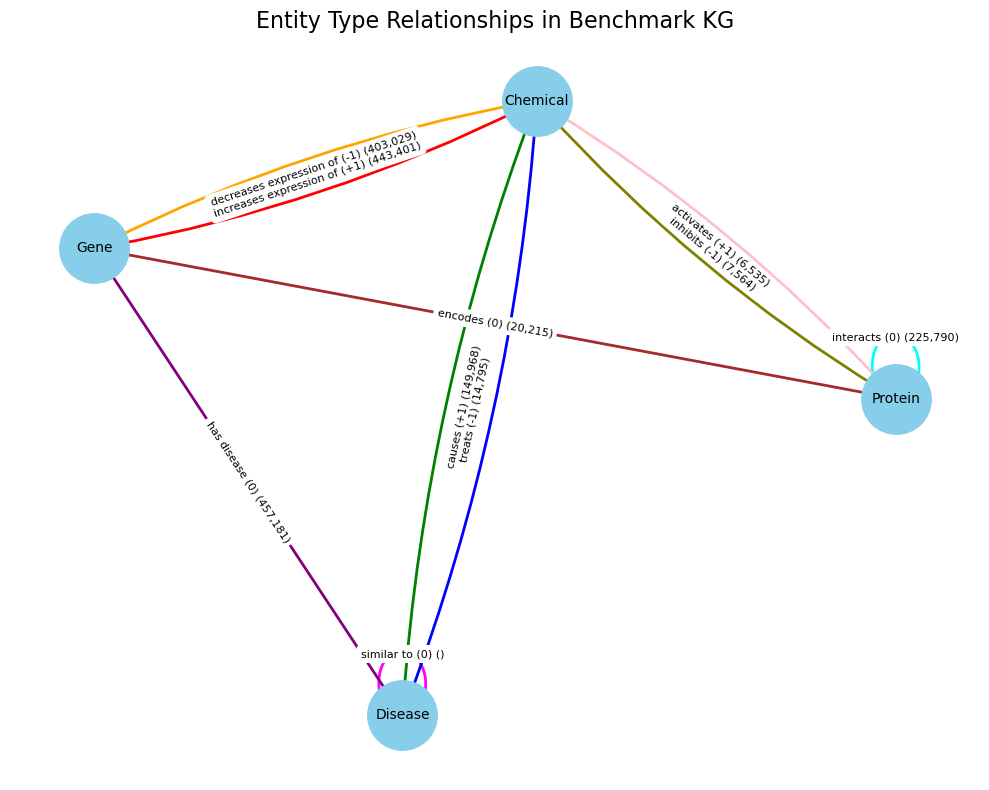

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import itertools

# --- Data Setup ---
# Each tuple contains (source_type, target_type, relations dictionary)
data = [
    ("Chemical", "Disease", {"causes (+1)": '149,968', "treats (-1)": '14,795'}),
    ("Chemical", "Gene", {"decreases expression of (-1)": '403,029', "increases expression of (+1)": '443,401'}),  
    ("Gene", "Disease", {"has disease (0)": '457,181'}),
    ("Gene", "Protein", {"encodes (0)": '20,215'}),
    ("Chemical", "Protein", {"activates (+1)": '6,535', "inhibits (-1)": '7,564'}),
    ("Protein", "Protein", {"interacts (0)": '225,790'}),
    ("Disease", "Disease", {"similar to (0)": ''}),
]

# --- Create Graph ---
G = nx.MultiDiGraph()

# Add unique entity types as nodes.
nodes = set()
for source, target, _ in data:
    nodes.add(source)
    nodes.add(target)
G.add_nodes_from(nodes)

# Set up a cycle of diverse colors.
colors_list = ["blue", "green", "red", "orange", "purple", "brown", "pink", "olive", "cyan", "magenta"]
color_cycle = itertools.cycle(colors_list)
relation_colors = {}

# Add each relation as an edge with its assigned color and store its count.
for source, target, relations in data:
    for rel, count in relations.items():
        if rel not in relation_colors:
            relation_colors[rel] = next(color_cycle)
        G.add_edge(source, target, relation=rel, count=count, color=relation_colors[rel])

# --- Compute Layout ---
# Use a spring layout with an increased optimal distance (k) and more iterations.
pos = nx.spring_layout(G, k=20.0, iterations=400)

# Optional: manually adjust positions if needed.
# For example, if Chemical is still too central, you could shift it a bit:
# pos['Chemical'][0] -= 0.3  # shifts Chemical a bit to the left

# --- Draw Nodes ---
plt.figure(figsize=(10, 8))
# Increase node_size to make entity circles bigger.
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=2500)

# --- Draw Edges with Curvature to Avoid Overlap ---
# Count parallel edges between each pair.
edge_counts = {}
for u, v, key in G.edges(keys=True):
    edge_counts[(u, v)] = edge_counts.get((u, v), 0) + 1

# Draw each edge with a slight curvature.
edge_idx = {}
for u, v, key, edge_data in G.edges(keys=True, data=True):
    if (u, v) not in edge_idx:
        edge_idx[(u, v)] = 0
    total = edge_counts[(u, v)]
    # Compute curvature so that parallel edges are spread out.
    rad = 0.15 * (edge_idx[(u, v)] - (total - 1) / 2)
    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(u, v)],
        connectionstyle=f'arc3, rad = {rad}',
        edge_color=edge_data['color'],
        arrows=True,
        arrowsize=20,
        width=2
    )
    edge_idx[(u, v)] += 1

# --- Draw Node Labels ---
nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')

# --- Draw Edge Labels (Relation and Count) ---
edge_labels = {}
for u, v, key, edge_data in G.edges(keys=True, data=True):
    label = f"{edge_data['relation']} ({edge_data['count']})"
    if (u, v) in edge_labels:
        edge_labels[(u, v)] += "\n" + label
    else:
        edge_labels[(u, v)] = label

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='black', font_size=8)

# --- Final Plot Adjustments ---
plt.title("Entity Type Relationships in Benchmark KG", fontsize=16)
plt.axis('off')
plt.tight_layout()
# Uncomment the next line to save the figure
plt.savefig("/home/vmottaqi/kg/kg_versions/benchmark_kg_schema_Apr112025.png", dpi=1200)
plt.show()
